## Notes: Needs improvements giving wrong results

## ✅ Cell 1 — Install deps (Kaggle)

In [1]:
# !pip -q install -U "transformers>=4.50.0" accelerate bitsandbytes sentencepiece

In [2]:
# !pip -q install -U bitsandbytes accelerate
# import importlib, importlib.metadata, sys
# print("bitsandbytes version:", importlib.metadata.version("bitsandbytes"))

## ✅ Cell 2 — Imports + small utilities

In [3]:
import os, json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
)

from tqdm.auto import tqdm
import matplotlib.pyplot as plt


2026-01-02 09:24:27.736294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767345867.759140     857 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767345867.765768     857 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## ✅ Cell 3 — Config

In [19]:
# ============ PATHS ============
DATA_DIR = "/kaggle/input/panel-det-yolov5-results/runs/kept/crops/blots/batch_000"   # <-- change this
OUT_DIR  = "/kaggle/working/medgemma_zero_shot_out--2"

# ============ IO ============
RECURSIVE = True
ALLOWED_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
MAX_IMAGES = None      # set like 5000 for limit, or None for all
SAVE_FILENAME_COLUMN = True

# ============ MODEL ============
MODEL_ID = "google/medgemma-4b-it"

# For Kaggle T4 (16GB), 4-bit is usually safest.
LOAD_IN_4BIT = False

# ============ INFERENCE ============
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Show samples
N_RANDOM_PER_CLASS_MAIN = 6
N_RANDOM_PER_CLASS_SUB  = 6
MAX_CLASSES_TO_SHOW = 12  # safety for display


## ✅ Cell 4 — Repro + output dir

In [20]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
print("DEVICE:", DEVICE)
print("OUT_DIR:", OUT_DIR)

DEVICE: cuda
OUT_DIR: /kaggle/working/medgemma_zero_shot_out--2


# ✅ Cell 5 — Load MedGemma (4-bit optional)

In [6]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
import os

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")  # set in Kaggle Secrets

if not hf_token or not hf_token.startswith("hf_"):
    raise RuntimeError("HF_TOKEN missing/invalid. Add it in Kaggle Secrets (Add-ons -> Secrets).")

login(token=hf_token)  # caches token for this session
print("✅ Hugging Face login OK")

✅ Hugging Face login OK


In [7]:
def pick_dtype():
    # T4 (7.5) doesn't support bf16 well → prefer fp16 on most Kaggle GPUs.
    if not torch.cuda.is_available():
        return torch.float32
    major, minor = torch.cuda.get_device_capability()
    # Ampere (8.0+) supports bf16; otherwise fp16
    return torch.bfloat16 if major >= 8 else torch.float16

DTYPE = pick_dtype()
print("Using dtype:", DTYPE)

quant_config = None
if LOAD_IN_4BIT and torch.cuda.is_available():
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=DTYPE,
    )

print("Loading processor...")
processor = AutoProcessor.from_pretrained(MODEL_ID)

print("Loading model...")
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    device_map="auto" if torch.cuda.is_available() else None,
    torch_dtype=DTYPE if torch.cuda.is_available() else torch.float32,
    quantization_config=quant_config,
)

model.eval()
print("Model loaded.")

Using dtype: torch.float16
Loading processor...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading model...


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded.


In [8]:
# from transformers import pipeline
# from PIL import Image
# import requests
# import torch

# pipe = pipeline(
#     "image-text-to-text",
#     model="google/medgemma-4b-it",
#     torch_dtype=torch.bfloat16,
#     device="cuda",
# )

## ✅ Cell 6 — Image discovery (folder loading)

In [9]:
def is_image_file(p: Path) -> bool:
    return p.suffix.lower() in ALLOWED_EXT

def list_images(root: str, recursive: bool = True):
    rootp = Path(root)
    if not rootp.exists():
        raise FileNotFoundError(f"DATA_DIR not found: {root}")
    if rootp.is_file() and is_image_file(rootp):
        return [rootp]

    if recursive:
        files = [p for p in rootp.rglob("*") if p.is_file() and is_image_file(p)]
    else:
        files = [p for p in rootp.glob("*") if p.is_file() and is_image_file(p)]
    files.sort()
    return files

image_paths = list_images(DATA_DIR, RECURSIVE)
if MAX_IMAGES is not None:
    image_paths = image_paths[:MAX_IMAGES]

print(f"Found {len(image_paths)} images")
print("Example:", image_paths[0] if image_paths else None)

Found 100 images
Example: /kaggle/input/panel-det-yolov5-results/runs/kept/crops/blots/batch_000/000000__IJFO-2025-1819384-g007__f66a6b2b__d000.png


## ✅ Cell 7 — Zero-shot classifier with real option-probabilities

his computes normalized probability over your options using the model’s next-token distribution.
We force answers to be single-letter choices so we can score them cleanly.

In [10]:
# -------------------------------
# LABELS (letters only)
# -------------------------------
MAIN_LABELS = {"A": "imaging", "B": "non_imaging"}

# Stage-2: make blot a dedicated binary decision (fixes "everything microscopy")
IMAGING2_LABELS = {"A": "blot", "B": "other_imaging"}

# Stage-3: only if other_imaging
IMAGING3_LABELS = {
    "A": "microscopy",
    "B": "histology_pathology",
    "C": "medical",
    "D": "other_image",
}

SYSTEM_TEXT = (
    "You are a strict scientific figure panel classifier. "
    "Follow instructions exactly. Output only the requested letter."
)

def build_messages_main(img):
    user_text = (
        "Task: Decide if this panel is IMAGING or NON-IMAGING.\n"
        "IMAGING: microscopy photos, western blots/gels, histology slides, radiology/clinical photos.\n"
        "NON-IMAGING: plots/graphs/charts, tables, diagrams, schematics, flowcharts, pure text.\n\n"
        "Answer with exactly one letter:\n"
        "A = IMAGING\n"
        "B = NON-IMAGING"
    )
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_TEXT}]},
        {"role": "user", "content": [{"type": "text", "text": user_text}, {"type": "image", "image": img}]},
    ]

def build_messages_imaging2(img):
    user_text = (
        "Task: This is IMAGING. Decide if it is a BLOT/GEL or NOT.\n"
        "BLOT/GEL cues: multiple parallel lanes, dark bands on light background OR light bands on dark background, "
        "rectangular gel panels, molecular weight marker ladders, high-contrast grayscale, band patterns.\n"
        "NOT BLOT: microscopy of cells/tissue, histology slides, radiology, clinical photos.\n"
        "Ignore labels like (A,B,C), arrows, scale bars, text.\n\n"
        "Answer with exactly one letter:\n"
        "A = BLOT/GEL (western blot / gel electrophoresis)\n"
        "B = NOT BLOT (other imaging)"
    )
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_TEXT}]},
        {"role": "user", "content": [{"type": "text", "text": user_text}, {"type": "image", "image": img}]},
    ]

def build_messages_imaging3(img):
    user_text = (
        "Task: This is IMAGING and NOT a BLOT. Choose the best subtype.\n"
        "MICROSCOPY: cells/organisms in micrographs, fluorescence, confocal, EM.\n"
        "HISTOLOGY_PATHOLOGY: H&E/IHC stained tissue sections, slide-like textures.\n"
        "MEDICAL: X-ray, CT, MRI, ultrasound, endoscopy, dermoscopy, clinical imaging.\n"
        "OTHER_IMAGE: photos or biomedical images not matching above.\n"
        "Ignore panel letters, arrows, scale bars, text overlays.\n\n"
        "Answer with exactly one letter:\n"
        "A = MICROSCOPY\n"
        "B = HISTOLOGY_PATHOLOGY\n"
        "C = MEDICAL\n"
        "D = OTHER_IMAGE"
    )
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_TEXT}]},
        {"role": "user", "content": [{"type": "text", "text": user_text}, {"type": "image", "image": img}]},
    ]

def _single_token_id(tokenizer, letter):
    # try both "A" and " A"
    for s in (letter, " " + letter):
        ids = tokenizer.encode(s, add_special_tokens=False)
        if len(ids) == 1:
            return ids[0]
    return None

@torch.inference_mode()
def score_choices_one_step(messages, choice_map):
    """
    Stable one-step scoring over letter choices.
    Uses generate(output_scores=True) and float32 stable softmax.
    """
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    for k, v in inputs.items():
        if isinstance(v, torch.Tensor):
            inputs[k] = v.to(model.device)

    # One token generation; return per-step logits
    gen = model.generate(
        **inputs,
        max_new_tokens=1,
        do_sample=False,
        return_dict_in_generate=True,
        output_scores=True,
    )

    # logits for the first generated token
    step_logits = gen.scores[0][0].float()  # float32 for stability
    step_logits = step_logits - step_logits.max()  # stable softmax
    probs = torch.softmax(step_logits, dim=-1)

    # Map each choice letter to its token prob
    tok = processor.tokenizer
    raw = {}
    for letter in choice_map.keys():
        tid = _single_token_id(tok, letter)
        if tid is None:
            raw[letter] = 0.0
        else:
            raw[letter] = float(probs[tid].item())

    denom = sum(raw.values())
    if not np.isfinite(denom) or denom <= 0:
        # uniform fallback (never NaN)
        norm = {k: 1.0 / len(raw) for k in raw}
    else:
        norm = {k: v / denom for k, v in raw.items()}

    best_letter = max(norm.items(), key=lambda x: x[1])[0]
    return best_letter, float(norm[best_letter]), norm

## ✅ Cell 8 — Run inference + write results (CSV/Parquet) + resume

In [21]:
from PIL import Image

def safe_open_image(path):
    try:
        img = Image.open(path).convert("RGB")
        return img, None
    except Exception as e:
        return None, str(e)

def upscale_if_small(img, min_side=512):
    w, h = img.size
    if min(w, h) >= min_side:
        return img
    scale = min_side / min(w, h)
    nw, nh = int(round(w*scale)), int(round(h*scale))
    return img.resize((nw, nh), Image.BICUBIC)

OUT_CSV = str(Path(OUT_DIR) / "predictions.csv")

done = set()
rows = []
if Path(OUT_CSV).exists():
    prev = pd.read_csv(OUT_CSV)
    if "path" in prev.columns:
        done = set(prev["path"].astype(str).tolist())
        rows = prev.to_dict("records")
    print(f"[RESUME] Loaded {len(done)} already processed items")

pbar = tqdm(image_paths, total=len(image_paths))
n_err = 0

for p in pbar:
    p = Path(p)
    p_str = str(p)
    if p_str in done:
        continue

    img, err = safe_open_image(p)
    if err is not None:
        rows.append({"path": p_str, "main_pred": "", "main_conf": "", "sub_pred": "", "sub_conf": "", "error": err})
        n_err += 1
        continue

    # upscaling
    img = upscale_if_small(img, 512)

    # Stage-1
    m_letter, m_conf, _ = score_choices_one_step(build_messages_main(img), MAIN_LABELS)
    main_label = MAIN_LABELS[m_letter]

    sub_label = ""
    sub_conf = ""

    if main_label == "imaging":
        # Stage-2 (blot vs other)
        s2_letter, s2_conf, _ = score_choices_one_step(build_messages_imaging2(img), IMAGING2_LABELS)
        s2_label = IMAGING2_LABELS[s2_letter]

        if s2_label == "blot":
            sub_label = "blot"
            sub_conf = round(s2_conf, 4)
        else:
            # Stage-3 (microscopy vs histo vs medical vs other)
            s3_letter, s3_conf, _ = score_choices_one_step(build_messages_imaging3(img), IMAGING3_LABELS)
            sub_label = IMAGING3_LABELS[s3_letter]
            sub_conf = round(s3_conf, 4)

    row = {
        "path": p_str,
        "main_pred": main_label,
        "main_conf": round(m_conf, 4),
        "sub_pred": sub_label,
        "sub_conf": sub_conf,
        "error": "",
    }
    rows.append(row)

    if len(rows) % 50 == 0:
        pd.DataFrame(rows).to_csv(OUT_CSV, index=False)

pd.DataFrame(rows).to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
print("Errors:", n_err)

df = pd.DataFrame(rows)
df.head(20)


  0%|          | 0/100 [00:00<?, ?it/s]

Saved: /kaggle/working/medgemma_zero_shot_out--2/predictions.csv
Errors: 0


,path,main_pred,main_conf,sub_pred,sub_conf,error
0,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,
1,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,
2,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,
3,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,
4,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,
5,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,
6,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,
7,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,
8,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,
9,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5,


## ✅ Cell 9 — Random sample viewer (per predicted class)

Random samples by MAIN prediction


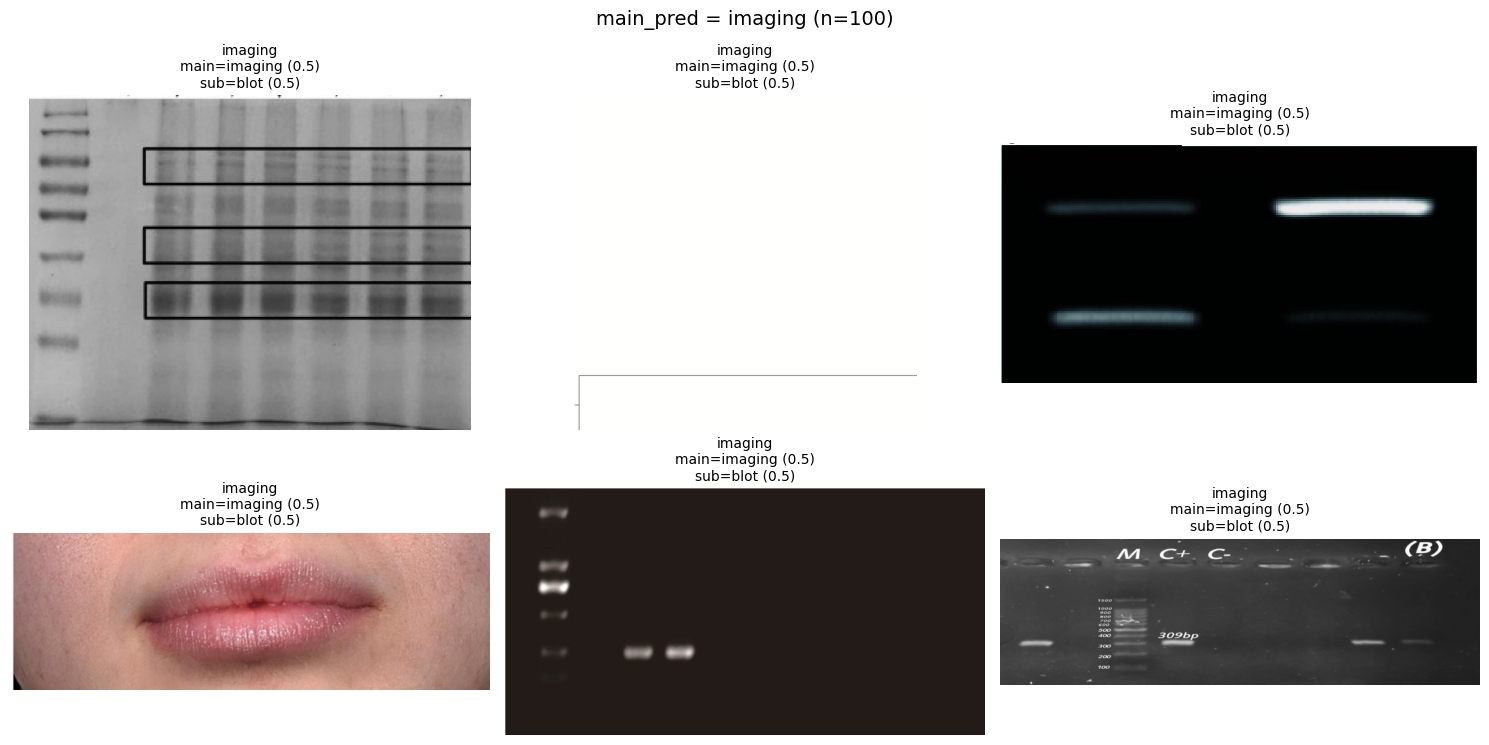

Random samples by SUB prediction (only imaging)


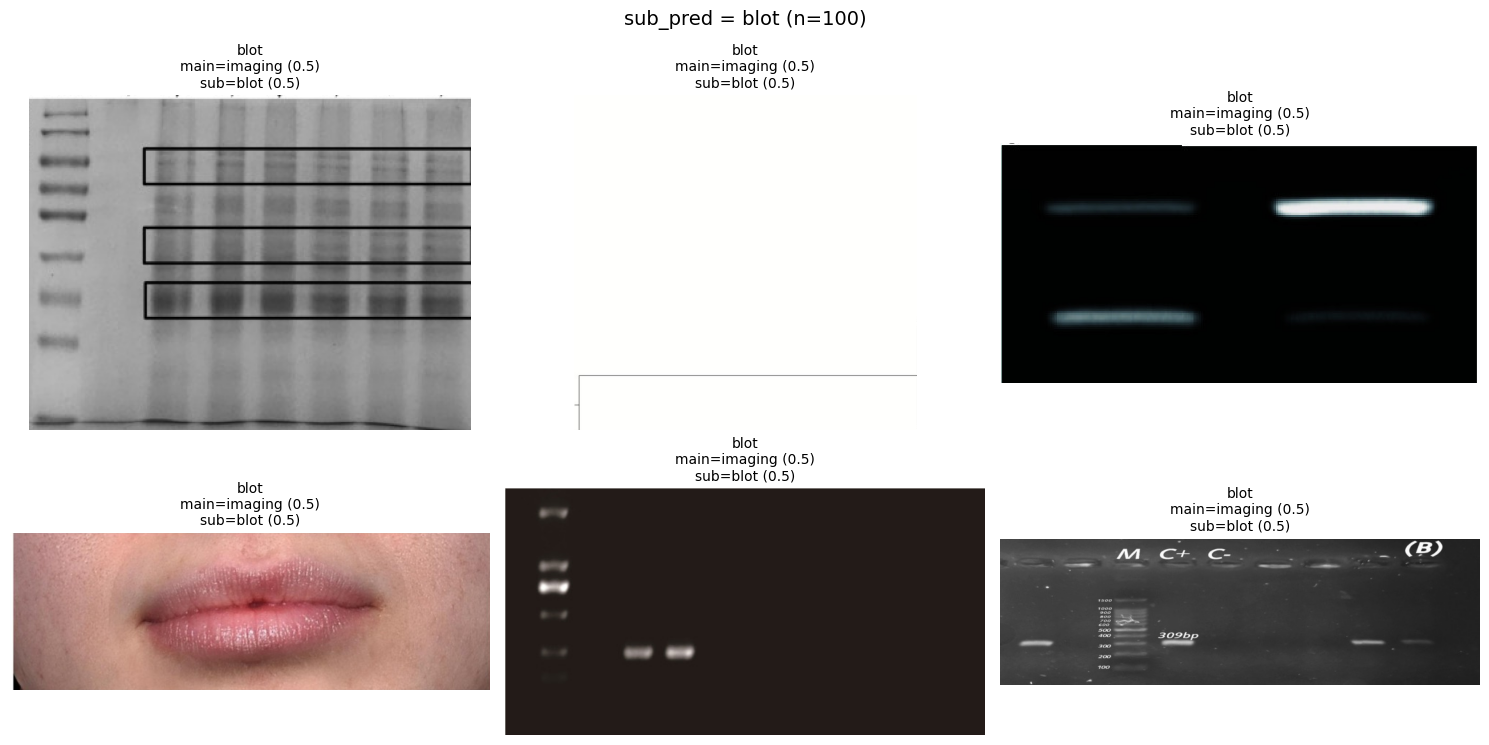

In [22]:
def show_samples(df, by_col, n_per_class=6, title=None, seed=42, max_classes=12):
    if title:
        print(title)
    dd = df[df["error"].fillna("") == ""].copy()
    dd = dd[dd[by_col].fillna("").astype(str).str.len() > 0]
    classes = sorted(dd[by_col].unique().tolist())
    if len(classes) == 0:
        print("No classes to show.")
        return

    random.Random(seed).shuffle(classes)
    classes = classes[:max_classes]

    for cls in classes:
        subset = dd[dd[by_col] == cls]
        if len(subset) == 0:
            continue
        take = subset.sample(min(n_per_class, len(subset)), random_state=seed)
        paths = take["path"].tolist()

        n = len(paths)
        cols = min(3, n)
        rows = math.ceil(n / cols)

        plt.figure(figsize=(5*cols, 4*rows))
        for i, path in enumerate(paths, start=1):
            img = Image.open(path).convert("RGB")
            r = take.iloc[i-1]
            main_s = f"main={r['main_pred']} ({r['main_conf']})"
            sub_s  = f"sub={r['sub_pred']} ({r['sub_conf']})" if r["sub_pred"] else ""
            caption = f"{cls}\n{main_s}\n{sub_s}".strip()

            ax = plt.subplot(rows, cols, i)
            ax.imshow(img)
            ax.set_title(caption, fontsize=10)
            ax.axis("off")

        plt.suptitle(f"{by_col} = {cls} (n={len(subset)})", fontsize=14)
        plt.tight_layout()
        plt.show()

show_samples(df, "main_pred", n_per_class=N_RANDOM_PER_CLASS_MAIN,
             title="Random samples by MAIN prediction", seed=SEED, max_classes=MAX_CLASSES_TO_SHOW)

show_samples(df[df["main_pred"]=="imaging"], "sub_pred", n_per_class=N_RANDOM_PER_CLASS_SUB,
             title="Random samples by SUB prediction (only imaging)", seed=SEED, max_classes=MAX_CLASSES_TO_SHOW)

## ✅ Cell 10 — Quick summary tables

In [13]:
ok = df[df["error"].fillna("") == ""].copy()

print("MAIN distribution:")
display(ok["main_pred"].value_counts(dropna=False).to_frame("count"))

print("\nSUB distribution (imaging only):")
display(ok.loc[ok["main_pred"]=="imaging", "sub_pred"].value_counts(dropna=False).to_frame("count"))

print("\nLowest-confidence MAIN predictions:")
display(ok.sort_values("main_conf").head(20)[["path","main_pred","main_conf","sub_pred","sub_conf"]])


MAIN distribution:


,count
main_pred,
imaging,100



SUB distribution (imaging only):


,count
sub_pred,
blot,100



Lowest-confidence MAIN predictions:


,path,main_pred,main_conf,sub_pred,sub_conf
88,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
89,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
90,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
91,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
92,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
93,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
94,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
95,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
96,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
1,/kaggle/input/panel-det-yolov5-results/runs/ke...,imaging,0.5,blot,0.5
